# Import

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("..")

from src.preprocessing import (
    convert_to_cnn2d_input, load_numpy_arrays
)
from src.model import build_cnn1d, build_cnn2d
from src.train import train_model, set_seed

#  CNN 1D

In [4]:
dataset_path = "../data/dataset.csv"

X, y = load_dataset(dataset_path)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
X_train_scaled, X_val_scaled, X_test_scaled, scaler = scale_features(X_train, X_val, X_test)

# reshape → (N, G, 1)
X_train_scaled = X_train_scaled[..., np.newaxis]
X_val_scaled = X_val_scaled[..., np.newaxis]
X_test_scaled = X_test_scaled[..., np.newaxis]

print("1D CNN train shape:", X_train_scaled.shape)

Feature shape: (16290, 12413)
Labels shape: (16290,)
Label distribution:
 0    10726
1     5564
Name: label, dtype: int64


In [6]:
model_1d = build_cnn1d(input_shape=(X_train_scaled.shape[1], 1))
model_1d, history_1d = train_model(
    model_1d,
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    save_path="../models/cnn1d_best.h5",
    epochs=20,
    batch_size=64,
    monitor="val_loss",
    mode="min"
)

2025-09-19 07:44:47.161006: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-19 07:44:47.637399: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22401 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:3b:00.0, compute capability: 8.6
2025-09-19 07:44:47.638044: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22416 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:86:00.0, compute capability: 8.6


Epoch 1/20


2025-09-19 07:44:50.210634: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8907
2025-09-19 07:44:53.135141: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


163/163 [==============================] - ETA: 0s - loss: 0.6061 - acc: 0.6584
Epoch 1: val_loss improved from inf to 0.57748, saving model to ../models/cnn1d_best.h5
163/163 [==============================] - 13s 52ms/step - loss: 0.6061 - acc: 0.6584 - val_loss: 0.5775 - val_acc: 0.6586
Epoch 2/20
163/163 [==============================] - ETA: 0s - loss: 0.5519 - acc: 0.6800
Epoch 2: val_loss improved from 0.57748 to 0.56767, saving model to ../models/cnn1d_best.h5
163/163 [==============================] - 8s 47ms/step - loss: 0.5519 - acc: 0.6800 - val_loss: 0.5677 - val_acc: 0.7058
Epoch 3/20
163/163 [==============================] - ETA: 0s - loss: 0.5323 - acc: 0.7095
Epoch 3: val_loss improved from 0.56767 to 0.54557, saving model to ../models/cnn1d_best.h5
163/163 [==============================] - 8s 48ms/step - loss: 0.5323 - acc: 0.7095 - val_loss: 0.5456 - val_acc: 0.7296
Epoch 4/20
163/163 [==============================] - ETA: 0s - loss: 0.5190 - acc: 0.7237
Epoch 4:

# CNN 2D

In [12]:
X_responder, y_responder, X_nonresponder, y_nonresponder = load_numpy_arrays("../data/npy")

X = np.concatenate((X_responder, X_nonresponder), axis=0)
y = np.concatenate((y_responder, y_nonresponder), axis=None)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=25)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=25)

X_train = convert_to_cnn2d_input(X_train)
X_val   = convert_to_cnn2d_input(X_val)
X_test  = convert_to_cnn2d_input(X_test)

print("2D CNN train shape:", X_train.shape)
print("2D CNN val shape:", X_val.shape)
print("2D CNN test shape:", X_test.shape)

2D CNN train shape: (10425, 383, 186, 1)
2D CNN val shape: (2607, 383, 186, 1)
2D CNN test shape: (3258, 383, 186, 1)


In [13]:
model_2d = build_cnn2d(input_shape=(X_train.shape[1], X_train.shape[2], 1))
model_2d, history_2d = train_model(
    model_2d,
    X_train, y_train,
    X_val, y_val,
    save_path="../models/cnn2d_best.h5",
    epochs=20,
    batch_size=64,
    monitor="val_loss",
    mode="min"
)

Epoch 1/20
163/163 [==============================] - ETA: 0s - loss: 0.6369 - acc: 0.6496
Epoch 1: val_loss improved from inf to 0.60197, saving model to ../models/cnn2d_best.h5
163/163 [==============================] - 25s 144ms/step - loss: 0.6369 - acc: 0.6496 - val_loss: 0.6020 - val_acc: 0.6586
Epoch 2/20
163/163 [==============================] - ETA: 0s - loss: 0.5932 - acc: 0.6727
Epoch 2: val_loss improved from 0.60197 to 0.58594, saving model to ../models/cnn2d_best.h5
163/163 [==============================] - 21s 127ms/step - loss: 0.5932 - acc: 0.6727 - val_loss: 0.5859 - val_acc: 0.7039
Epoch 3/20
163/163 [==============================] - ETA: 0s - loss: 0.5799 - acc: 0.6846
Epoch 3: val_loss improved from 0.58594 to 0.57946, saving model to ../models/cnn2d_best.h5
163/163 [==============================] - 21s 127ms/step - loss: 0.5799 - acc: 0.6846 - val_loss: 0.5795 - val_acc: 0.6847
Epoch 4/20
163/163 [==============================] - ETA: 0s - loss: 0.5678 - acc:

# Learning curve

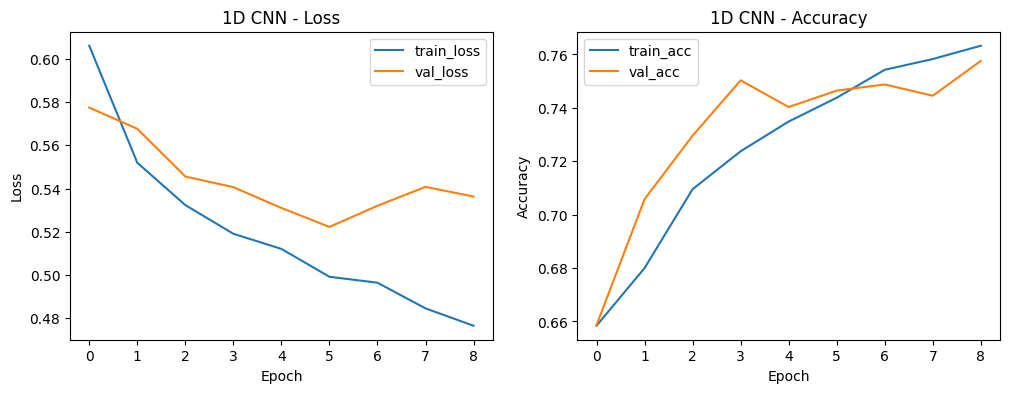

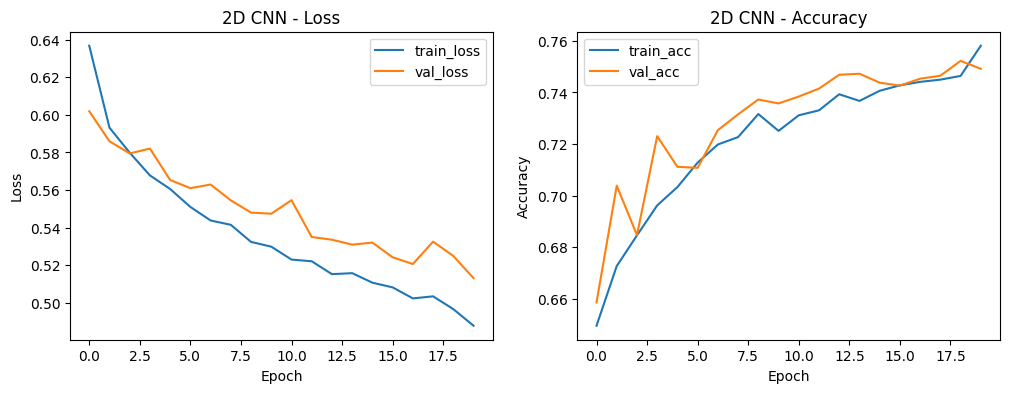

In [14]:
def plot_history(history, title="Training History"):
    plt.figure(figsize=(12,4))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend()
    # Accuracy
    if "acc" in history.history:
        plt.subplot(1,2,2)
        plt.plot(history.history["acc"], label="train_acc")
        plt.plot(history.history["val_acc"], label="val_acc")
        plt.title(f"{title} - Accuracy")
        plt.xlabel("Epoch"); plt.ylabel("Accuracy")
        plt.legend()
    plt.show()

plot_history(history_1d, "1D CNN")
plot_history(history_2d, "2D CNN")